In [1]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import argparse
from nnfabrik.builder import get_data, get_trainer


from modified_neuralpredictors.create_model import stacked_core_full_gauss_readout
from modified_neuralpredictors.wandb_trainer import standard_trainer


random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

device = 'cuda:0'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"

# as filenames, we'll select all 7 datasets
filenames = [
    os.path.join(basepath, file) for file in os.listdir(basepath) if ".zip" in file
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "batch_size": 512,
    "scale": 0.25,
}

dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

In [14]:
behavs = []

for key in data_keys:
    single_behavs = []

    for batch in dataloaders['train'][key]:
        img, _, behav, pupil = batch
        single_behavs.append(behav)
    behavs.append(torch.cat(single_behavs))

2.52 	 1.0
2.81 	 1.0
4.12 	 1.0
2.14 	 1.0
2.39 	 1.0
2.15 	 1.0

0.14 	 1.0
0.13 	 1.0
0.13 	 0.99
0.15 	 1.0
0.14 	 1.0
0.06 	 1.0

-0.19 	 1.0
0.02 	 1.0
-0.48 	 0.99
0.02 	 1.0
-0.2 	 1.0
-0.03 	 1.0


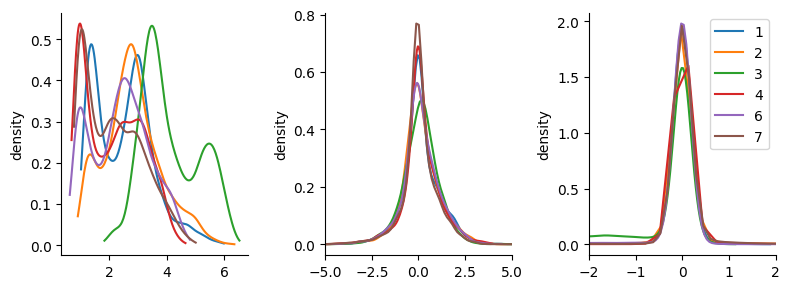

In [24]:
import numpy as np
from scipy import stats

fig, axs = plt.subplots(1, 3, figsize=(8, 3))

for num_animal, behav in enumerate(behavs):
    if num_animal == 4: continue
    data = behav[:, 0].cpu().numpy()
    print(data.mean().round(2), '\t', data.std().round(2))
    
    # Calculate KDE
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    density = kde(x_range)
    
    axs[0].plot(x_range, density, label=num_animal + 1)

axs[0].set_ylabel('density')
axs[0].set_xlabel('')
axs[0].spines[['top', 'right']].set_visible(False)
print()

for num_animal, behav in enumerate(behavs):
    if num_animal == 4: continue
    data = behav[:, 1].cpu().numpy()
    print(data.mean().round(2), '\t', data.std().round(2))
    
    # Calculate KDE
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    density = kde(x_range)
    
    axs[1].plot(x_range, density, label=num_animal + 1)
axs[1].set_xlim(-5, 5)
axs[1].set_ylabel('density')
axs[1].set_xlabel('')
axs[1].spines[['top', 'right']].set_visible(False)
print()

for num_animal, behav in enumerate(behavs):
    if num_animal == 4: continue
    data = behav[:, 2].cpu().numpy()
    print(data.mean().round(2), '\t', data.std().round(2))

    # Calculate KDE
    kde = stats.gaussian_kde(data)
    x_range = np.linspace(data.min(), data.max(), 200)
    density = kde(x_range)
    
    axs[2].plot(x_range, density, label=num_animal + 1)
axs[2].set_xlim(-2, 2)
axs[2].set_ylabel('density')
axs[2].set_xlabel('')
axs[2].spines[['top', 'right']].set_visible(False)

plt.legend()
plt.tight_layout()
plt.savefig('plots/behavior_distr.pdf')
plt.show()